# WBF Ensemble — Kidney Stone Detection
### DINOv3 + BYOL + MAE → Weighted Box Fusion

In [1]:
# ── Cell 1: Install ──
!pip install -q ensemble-boxes ultralytics
print('✅ Done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.7 MB/s eta 0:00:00a 0:00:01
✅ Done


In [2]:
# ── Cell 2: Imports ──
import os, glob, cv2, json, torch, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from tqdm.notebook import tqdm
from ensemble_boxes import weighted_boxes_fusion
from ultralytics import YOLO
warnings.filterwarnings('ignore')

INPUT  = '/kaggle/input'
OUTPUT = '/kaggle/working'
IMG_SIZE = 640

# WBF parameters
WBF_WEIGHTS      = [1.0, 1.0, 1.0]   # [DINOv3, BYOL, MAE]
WBF_IOU_THR      = 0.55
WBF_SKIP_BOX_THR = 0.05
CONF_THR         = 0.25

print('✅ Imports done')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Imports done
GPU: Tesla T4


In [3]:
# MAE checkpoint structure check
import numpy as np
torch.serialization.add_safe_globals([np.core.multiarray.scalar])

for ds_name, key in [('dataset1', 'mae_ds1.pth'), ('dataset2', 'mae_ds2.pth')]:
    path = f'/kaggle/input/datasets/isratjahansarker/wbf-kidneystonedetection-capstone/{key}'
    ckpt = torch.load(path, map_location='cpu', weights_only=False)
    print(f'\n[{ds_name}] {key}')
    if isinstance(ckpt, dict):
        print(f'  Keys: {list(ckpt.keys())}')
        for k, v in ckpt.items():
            if hasattr(v, 'shape'):
                print(f'    {k}: {v.shape}')
            elif isinstance(v, dict):
                print(f'    {k}: dict with {len(v)} keys')
            else:
                print(f'    {k}: {type(v).__name__} = {v}')
    elif isinstance(ckpt, torch.nn.Module):
        print(f'  Type: {type(ckpt).__name__}')


[dataset1] mae_ds1.pth
  Keys: ['model', 'epoch', 'map50', 'phase']
    model: dict with 418 keys
    epoch: int = 42
    map50: float = 0.896386752421268
    phase: int = 2

[dataset2] mae_ds2.pth
  Keys: ['model', 'epoch', 'map50', 'class_aps', 'phase']
    model: dict with 418 keys
    epoch: int = 19
    map50: ()
    class_aps: dict with 3 keys
    phase: int = 2


In [3]:
# ── Cell 3: Config — paths ──
BASE = '/kaggle/input/datasets/isratjahansarker/wbf-kidneystonedetection-capstone'

MODELS = {
    'dataset1': {
        'dinov3': f'{BASE}/dinov3_ds1.pt',
        'byol'  : f'{BASE}/byol_ds1.pt',
        'mae'   : f'{BASE}/mae_ds1.pth',
        'test_images': f'{BASE}/kidney Stone.v2i.yolov12/test/images',
        'test_labels': f'{BASE}/kidney Stone.v2i.yolov12/test/labels',
        'classes': ['kidney_stone_type2', 'No_stone', 'kidney_stone_type1'],
        'nc': 3,
    },
    'dataset2': {
        'dinov3': f'{BASE}/dinov3_ds2.pt',
        'byol'  : f'{BASE}/byol_ds2.pt',
        'mae'   : f'{BASE}/mae_ds2.pth',
        'test_images': f'{BASE}/Kidney stone detection.v1i.yolov12/test/images',
        'test_labels': f'{BASE}/Kidney stone detection.v1i.yolov12/test/labels',
        'classes': ['kidney_stone_type2', 'No_stone', 'kidney_stone_type1'],
        'nc': 3,
    },
}

# ── Verify all paths ──
print('Checking paths...')
all_ok = True
for ds_name, cfg in MODELS.items():
    print(f'\n  [{ds_name}]')
    for key, path in cfg.items():
        if key in ['classes', 'nc']:
            continue
        exists = os.path.exists(path)
        status = '✅' if exists else '❌'
        print(f'    {status} {key}: {path}')
        if not exists:
            all_ok = False

if not all_ok:
    print('\n⚠️  Some paths missing!')
else:
    print('\n✅ All paths found!')

Checking paths...

  [dataset1]
    ✅ dinov3: /kaggle/input/datasets/isratjahansarker/wbf-kidneystonedetection-capstone/dinov3_ds1.pt
    ✅ byol: /kaggle/input/datasets/isratjahansarker/wbf-kidneystonedetection-capstone/byol_ds1.pt
    ✅ mae: /kaggle/input/datasets/isratjahansarker/wbf-kidneystonedetection-capstone/mae_ds1.pth
    ✅ test_images: /kaggle/input/datasets/isratjahansarker/wbf-kidneystonedetection-capstone/kidney Stone.v2i.yolov12/test/images
    ✅ test_labels: /kaggle/input/datasets/isratjahansarker/wbf-kidneystonedetection-capstone/kidney Stone.v2i.yolov12/test/labels

  [dataset2]
    ✅ dinov3: /kaggle/input/datasets/isratjahansarker/wbf-kidneystonedetection-capstone/dinov3_ds2.pt
    ✅ byol: /kaggle/input/datasets/isratjahansarker/wbf-kidneystonedetection-capstone/byol_ds2.pt
    ✅ mae: /kaggle/input/datasets/isratjahansarker/wbf-kidneystonedetection-capstone/mae_ds2.pth
    ✅ test_images: /kaggle/input/datasets/isratjahansarker/wbf-kidneystonedetection-capstone/Kidney 

In [6]:
# ── Cell 4: Path finder 
print('=== /kaggle/input/ contents ===')
for item in sorted(os.listdir('/kaggle/input/')):
    print(f'  📁 {item}')

print('\n=== .pt and .pth files found ===')
for f in glob.glob('/kaggle/input/**/*.pt', recursive=True) + \
         glob.glob('/kaggle/input/**/*.pth', recursive=True):
    print(f'  {f}')

=== /kaggle/input/ contents ===
  📁 datasets

=== .pt and .pth files found ===
  /kaggle/input/datasets/isratjahansarker/wbf-kidneystonedetection-capstone/byol_ds1.pt
  /kaggle/input/datasets/isratjahansarker/wbf-kidneystonedetection-capstone/dinov3_ds2.pt
  /kaggle/input/datasets/isratjahansarker/wbf-kidneystonedetection-capstone/dinov3_ds1.pt
  /kaggle/input/datasets/isratjahansarker/wbf-kidneystonedetection-capstone/byol_ds2.pt
  /kaggle/input/datasets/isratjahansarker/wbf-kidneystonedetection-capstone/mae_ds2.pth
  /kaggle/input/datasets/isratjahansarker/wbf-kidneystonedetection-capstone/mae_ds1.pth


In [21]:
# ── Cell 5: MAE Model Loader (exact architecture) ──
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from functools import partial
from timm.models.vision_transformer import PatchEmbed, Block

class MAEViTBackbone(nn.Module):
    def __init__(self, img_size=640, patch_size=16,
                 embed_dim=768, depth=12, num_heads=12):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.feat_size = img_size // patch_size

        self.patch_embed = PatchEmbed(img_size, patch_size, 3, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches + 1, embed_dim), requires_grad=False)

        self.blocks = nn.ModuleList([
            Block(embed_dim, num_heads, 4.0, qkv_bias=True,
                  norm_layer=partial(nn.LayerNorm, eps=1e-6))
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim, eps=1e-6)

        fpn_dim = 256
        self.proj_p3 = nn.Sequential(
            nn.Conv2d(embed_dim, fpn_dim, 1, bias=False),
            nn.BatchNorm2d(fpn_dim), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(fpn_dim, fpn_dim, 2, stride=2),
            nn.BatchNorm2d(fpn_dim), nn.ReLU(inplace=True),
        )
        self.proj_p4 = nn.Sequential(
            nn.Conv2d(embed_dim, fpn_dim, 1, bias=False),
            nn.BatchNorm2d(fpn_dim), nn.ReLU(inplace=True),
        )
        self.proj_p5 = nn.Sequential(
            nn.Conv2d(embed_dim, fpn_dim, 1, bias=False),
            nn.BatchNorm2d(fpn_dim), nn.ReLU(inplace=True),
            nn.Conv2d(fpn_dim, fpn_dim, 3, stride=2, padding=1),
            nn.BatchNorm2d(fpn_dim), nn.ReLU(inplace=True),
        )
        self.proj_p6 = nn.Sequential(
            nn.Conv2d(embed_dim, fpn_dim, 1, bias=False),
            nn.BatchNorm2d(fpn_dim), nn.ReLU(inplace=True),
            nn.Conv2d(fpn_dim, fpn_dim, 3, stride=2, padding=1),
            nn.BatchNorm2d(fpn_dim), nn.ReLU(inplace=True),
            nn.Conv2d(fpn_dim, fpn_dim, 3, stride=2, padding=1),
            nn.BatchNorm2d(fpn_dim), nn.ReLU(inplace=True),
        )
        self.out_channels = fpn_dim
        self.tap_indices = [5, 8, 11]

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :]
        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        x = torch.cat([cls_token.expand(B, -1, -1), x], dim=1)

        features = {}
        for i, blk in enumerate(self.blocks):
            x = blk(x)
            if i in self.tap_indices:
                features[i] = x
        x = self.norm(x)
        features[len(self.blocks) - 1] = x

        def to_spatial(feat):
            feat = feat[:, 1:, :]
            feat = feat.reshape(B, self.feat_size, self.feat_size, self.embed_dim)
            return feat.permute(0, 3, 1, 2)

        p3 = self.proj_p3(to_spatial(features[self.tap_indices[0]]))
        p4 = self.proj_p4(to_spatial(features[self.tap_indices[1]]))
        p5 = self.proj_p5(to_spatial(features[self.tap_indices[2]]))
        p6 = self.proj_p6(to_spatial(features[self.tap_indices[2]]))
        return {"p3": p3, "p4": p4, "p5": p5, "p6": p6}


class MAEFasterRCNN(nn.Module):
    def __init__(self, num_classes=4, img_size=640):
        super().__init__()
        self.backbone = MAEViTBackbone(img_size=img_size)
        self.backbone.out_channels = 256

        anchor_sizes = ((16,24,32),(48,64,96),(128,160,192),(224,256,320))
        aspect_ratios = ((0.5, 1.0, 2.0),) * len(anchor_sizes)
        anchor_generator = AnchorGenerator(
            sizes=anchor_sizes, aspect_ratios=aspect_ratios)

        roi_pooler = torchvision.ops.MultiScaleRoIAlign(
            featmap_names=["p3","p4","p5","p6"],
            output_size=7, sampling_ratio=2)

        self.detector = FasterRCNN(
            backbone=self.backbone,
            num_classes=num_classes,
            rpn_anchor_generator=anchor_generator,
            box_roi_pool=roi_pooler,
            min_size=img_size, max_size=img_size,
            box_score_thresh=0.05, box_nms_thresh=0.5,
            box_detections_per_img=100,
            image_mean=[0.485,0.456,0.406],
            image_std=[0.229,0.224,0.225],
        )

    def forward(self, images, targets=None):
        return self.detector(images, targets)


def load_mae_model(weight_path, num_classes, device):
    import numpy as np
    try:
        torch.serialization.add_safe_globals([np.core.multiarray.scalar])
    except:
        pass
    try:
        ckpt = torch.load(weight_path, map_location='cpu', weights_only=False)
        state_dict = ckpt['model'] if isinstance(ckpt, dict) else ckpt

        # actual nc detect
        cls_key = 'detector.roi_heads.box_predictor.cls_score.weight'
        actual_nc = state_dict[cls_key].shape[0] if cls_key in state_dict else num_classes+1
        print(f'    Detected num_classes={actual_nc}')

        model = MAEFasterRCNN(num_classes=actual_nc)
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        model = model.to(device).eval()
        print(f'    ✅ MAE: loaded (missing={len(missing)}, unexpected={len(unexpected)})')
        return model, 'mae_frcnn'
    except Exception as e:
        print(f'    ⚠️  MAE load failed: {e}')
        return None, None


print('✅ MAE loader defined')

✅ MAE loader defined


In [22]:
# ── Cell 6: Load all 6 models ──
import shutil
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}\n')

loaded_models = {}

def load_yolo_model(weight_path, label):
    try:
        torch.serialization.add_safe_globals([np.core.multiarray.scalar])
    except:
        pass

    # .pt file → directly
    if weight_path.endswith('.pt'):
        try:
            model = YOLO(weight_path)
            print(f'    ✅ {label}: loaded as YOLO model')
            return model, 'yolo'
        except Exception as e:
            print(f'    ❌ {label}: FAILED — {e}')
            return None, None

    
    if weight_path.endswith('.pth'):
        pt_path = weight_path.replace('.pth', '_tmp.pt')
        try:
            shutil.copy(weight_path, pt_path)
            model = YOLO(pt_path)
            print(f'    ✅ {label}: loaded .pth as YOLO model')
            return model, 'yolo'
        except Exception:
            pass

        try:
            ckpt = torch.load(weight_path, map_location=device, weights_only=False)
            model_obj = ckpt.get('ema', ckpt.get('model', None)) if isinstance(ckpt, dict) else None
            if model_obj is not None:
                model_obj = model_obj.float().eval()
                yolo = YOLO('yolov8s.pt')
                yolo.model = model_obj.to(device)
                print(f'    ✅ {label}: loaded .pth state dict')
                return yolo, 'yolo'
            if isinstance(ckpt, torch.nn.Module):
                ckpt.eval()
                print(f'    ✅ {label}: loaded .pth as torch model')
                return ckpt, 'torch'
        except Exception as e:
            print(f'    ❌ {label}: FAILED — {e}')
            return None, None

    return None, None


for ds_name, cfg in MODELS.items():
    print(f'[{ds_name}]')
    loaded_models[ds_name] = {}
    nc = cfg['nc']

    m, t = load_yolo_model(cfg['dinov3'], 'DINOv3')
    loaded_models[ds_name]['dinov3'] = (m, t)

    m, t = load_yolo_model(cfg['byol'], 'BYOL')
    loaded_models[ds_name]['byol'] = (m, t)

    m, t = load_mae_model(cfg['mae'], nc, device)
    loaded_models[ds_name]['mae'] = (m, t)
    print()

Device: cuda

[dataset1]
    ✅ DINOv3: loaded as YOLO model
    ✅ BYOL: loaded as YOLO model
    Detected num_classes=2
    ✅ MAE: loaded (missing=0, unexpected=0)

[dataset2]
    ✅ DINOv3: loaded as YOLO model
    ✅ BYOL: loaded as YOLO model
    Detected num_classes=4
    ✅ MAE: loaded (missing=0, unexpected=0)



In [24]:
# ── Cell 7: Prediction functions ──
def predict_yolo(model, img_path, conf=0.01, valid_classes=None):
    results = model.predict(img_path, conf=conf, verbose=False, imgsz=IMG_SIZE)
    boxes, scores, labels = [], [], []
    for r in results:
        if r.boxes is None or len(r.boxes) == 0:
            continue
        h, w = r.orig_shape
        for box in r.boxes:
            cls_id = int(box.cls[0].cpu())
            if valid_classes is not None and cls_id not in valid_classes:
                continue
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            boxes.append([
                max(0.0, min(1.0, x1/w)),
                max(0.0, min(1.0, y1/h)),
                max(0.0, min(1.0, x2/w)),
                max(0.0, min(1.0, y2/h)),
            ])
            scores.append(float(box.conf[0].cpu()))
            labels.append(cls_id)
    return boxes, scores, labels


def predict_mae_frcnn(model, img_path, conf=0.01, num_classes=3):
    """Faster RCNN + ViT backbone prediction"""
    if model is None:
        return [], [], []
    try:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img  = (img - mean) / std
        tensor = torch.FloatTensor(img).permute(2, 0, 1).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(tensor)

        boxes, scores, labels = [], [], []
        out = outputs[0]
        h, w = img.shape[:2]

        for box, score, label in zip(
            out['boxes'].cpu().numpy(),
            out['scores'].cpu().numpy(),
            out['labels'].cpu().numpy()
        ):
            if score < conf:
                continue
            x1, y1, x2, y2 = box
          
            cls_id = max(0, int(label) - 1)
            if cls_id >= num_classes:
                continue
            boxes.append([
                max(0.0, min(1.0, x1/w)),
                max(0.0, min(1.0, y1/h)),
                max(0.0, min(1.0, x2/w)),
                max(0.0, min(1.0, y2/h)),
            ])
            scores.append(float(score))
            labels.append(cls_id)
        return boxes, scores, labels
    except Exception as e:
        return [], [], []


def predict_model(model, model_type, img_path, num_classes=3, valid_classes=None):
    if model is None:
        return [], [], []
    if model_type == 'yolo':
        return predict_yolo(model, img_path, valid_classes=valid_classes)
    elif model_type == 'mae_frcnn':
        return predict_mae_frcnn(model, img_path, num_classes=num_classes)
    elif model_type in ('full', 'torch'):
        try:
            return predict_yolo(model, img_path, valid_classes=valid_classes)
        except:
            return predict_mae_frcnn(model, img_path, num_classes=num_classes)
    return [], [], []


print('✅ Prediction functions ready')

✅ Prediction functions ready


In [25]:
# ── Cell 8: Run predictions + WBF on all images ──
def load_gt(label_path):
    boxes, labels = [], []
    if not os.path.exists(label_path):
        return boxes, labels
    with open(label_path) as f:
        for line in f:
            p = line.strip().split()
            if len(p) < 5: continue
            cls = int(p[0])
            cx, cy, w, h = float(p[1]), float(p[2]), float(p[3]), float(p[4])
            x1 = max(0, cx - w/2); y1 = max(0, cy - h/2)
            x2 = min(1, cx + w/2); y2 = min(1, cy + h/2)
            boxes.append([x1, y1, x2, y2])
            labels.append(cls)
    return boxes, labels

all_results   = {}
all_ind_preds = {}
all_gt        = {}

for ds_name, cfg in MODELS.items():
    print(f'\n{"="*55}')
    print(f'  {ds_name.upper()}')
    print(f'{"="*55}')

    img_dir = Path(cfg['test_images'])
    lbl_dir = Path(cfg['test_labels'])
    nc      = cfg['nc']
    valid_classes = set(range(nc))  

    if not img_dir.exists():
        print(f'  ❌ Test images not found: {img_dir}')
        all_results[ds_name]   = []
        all_ind_preds[ds_name] = {}
        all_gt[ds_name]        = {}
        continue

    img_paths = sorted(
        list(img_dir.glob('*.jpg')) +
        list(img_dir.glob('*.jpeg')) +
        list(img_dir.glob('*.png'))
    )
    print(f'  Found {len(img_paths)} test images')

    models_ds    = loaded_models[ds_name]
    ind_preds_ds = {'dinov3': [], 'byol': [], 'mae': []}
    gt_ds        = {}
    wbf_ds       = []

    for img_path in tqdm(img_paths, desc=ds_name):
        stem     = img_path.stem
        lbl_path = lbl_dir / (stem + '.txt')

        # Ground truth
        gt_boxes, gt_labels = load_gt(str(lbl_path))
        gt_ds[stem] = {'boxes': gt_boxes, 'labels': gt_labels}

        # Predictions from each model
        boxes_list, scores_list, labels_list = [], [], []
        for model_key in ['dinov3', 'byol', 'mae']:
            m, t = models_ds[model_key]
            b, s, l = predict_model(m, t, str(img_path), nc,
                                    valid_classes=valid_classes) 
            boxes_list.append(b)
            scores_list.append(s)
            labels_list.append(l)
            ind_preds_ds[model_key].append(
                {'stem': stem, 'boxes': b, 'scores': s, 'labels': l})

        # WBF
        if all(len(b) == 0 for b in boxes_list):
            wbf_ds.append({'stem': stem, 'boxes': [], 'scores': [], 'labels': []})
            continue

        fb, fs, fl = weighted_boxes_fusion(
            boxes_list, scores_list, labels_list,
            weights=WBF_WEIGHTS,
            iou_thr=WBF_IOU_THR,
            skip_box_thr=WBF_SKIP_BOX_THR,
        )
        keep = fs >= CONF_THR
        wbf_ds.append({
            'stem'  : stem,
            'boxes' : fb[keep].tolist(),
            'scores': fs[keep].tolist(),
            'labels': fl[keep].astype(int).tolist(),
        })

    all_results[ds_name]   = wbf_ds
    all_ind_preds[ds_name] = ind_preds_ds
    all_gt[ds_name]        = gt_ds

    total = sum(len(r['boxes']) for r in wbf_ds)
    print(f'\n  ✅ {len(wbf_ds)} images processed → {total} fused boxes')


  DATASET1
  Found 781 test images


dataset1:   0%|          | 0/781 [00:00<?, ?it/s]


  ✅ 781 images processed → 13726 fused boxes

  DATASET2
  Found 1005 test images


dataset2:   0%|          | 0/1005 [00:00<?, ?it/s]


  ✅ 1005 images processed → 1987 fused boxes


In [26]:
# ── Cell 9: Evaluation ──

def compute_iou(b1, b2):
    x1=max(b1[0],b2[0]); y1=max(b1[1],b2[1])
    x2=min(b1[2],b2[2]); y2=min(b1[3],b2[3])
    inter=max(0,x2-x1)*max(0,y2-y1)
    u=(b1[2]-b1[0])*(b1[3]-b1[1])+(b2[2]-b2[0])*(b2[3]-b2[1])-inter
    return inter/u if u>1e-6 else 0.0

def ap_at_iou(preds, gt_dict, iou_thr=0.5):
    score_tp, total_gt = [], 0
    for item in preds:
        stem = item['stem']
        gt   = gt_dict.get(stem, {'boxes':[], 'labels':[]})
        total_gt += len(gt['boxes'])
        matched  = set()
        order    = sorted(range(len(item['scores'])), key=lambda i: -item['scores'][i])
        for idx in order:
            pb, ps = item['boxes'][idx], item['scores'][idx]
            best_iou, best_j = 0.0, -1
            for j, gb in enumerate(gt['boxes']):
                if j in matched: continue
                iou = compute_iou(pb, gb)
                if iou > best_iou: best_iou, best_j = iou, j
            tp = 1 if best_iou >= iou_thr else 0
            if tp: matched.add(best_j)
            score_tp.append((ps, tp))
    if not score_tp: return 0.0, 0.0, 0.0, 0.0
    score_tp.sort(key=lambda x: -x[0])
    tp_cum = np.cumsum([x[1] for x in score_tp])
    fp_cum = np.cumsum([1-x[1] for x in score_tp])
    prec = tp_cum/(tp_cum+fp_cum+1e-8)
    rec  = tp_cum/(total_gt+1e-8)
    ap = sum(max(prec[rec>=t]) if (rec>=t).any() else 0 for t in np.linspace(0,1,11))/11
    p  = prec[-1]; r = rec[-1]
    f1 = 2*p*r/(p+r+1e-8)
    return ap, p, r, f1

def map5095(preds, gt_dict):
    return np.mean([ap_at_iou(preds, gt_dict, round(t,2))[0]
                    for t in np.arange(0.5, 1.0, 0.05)])

rows = []
for ds_name, cfg in MODELS.items():
    gt = all_gt.get(ds_name, {})
    if not gt: continue
    print(f'\n[{ds_name}]')

    # Individual models
    for mname in ['dinov3', 'byol', 'mae']:
        preds = all_ind_preds[ds_name][mname]
        ap50, p, r, f1 = ap_at_iou(preds, gt, 0.5)
        m5095 = map5095(preds, gt)
        print(f'  {mname.upper():8s} mAP50={ap50:.4f}  mAP50-95={m5095:.4f}  P={p:.4f}  R={r:.4f}  F1={f1:.4f}')
        rows.append({'Dataset': ds_name, 'Model': mname.upper(),
                     'mAP50': round(ap50,4), 'mAP50-95': round(m5095,4),
                     'Precision': round(p,4), 'Recall': round(r,4), 'F1': round(f1,4)})

    # WBF
    wbf_preds = all_results[ds_name]
    ap50, p, r, f1 = ap_at_iou(wbf_preds, gt, 0.5)
    m5095 = map5095(wbf_preds, gt)
    print(f'  {"WBF":8s} mAP50={ap50:.4f}  mAP50-95={m5095:.4f}  P={p:.4f}  R={r:.4f}  F1={f1:.4f}  ← Ensemble')
    rows.append({'Dataset': ds_name, 'Model': 'WBF',
                 'mAP50': round(ap50,4), 'mAP50-95': round(m5095,4),
                 'Precision': round(p,4), 'Recall': round(r,4), 'F1': round(f1,4)})

eval_df = pd.DataFrame(rows)
eval_df.to_csv(f'{OUTPUT}/wbf_evaluation.csv', index=False)
print('\n✅ Saved: wbf_evaluation.csv')


[dataset1]
  DINOV3   mAP50=0.0120  mAP50-95=0.0047  P=0.0089  R=0.6354  F1=0.0175
  BYOL     mAP50=0.0067  mAP50-95=0.0024  P=0.0084  R=0.5000  F1=0.0165
  MAE      mAP50=0.0088  mAP50-95=0.0030  P=0.0060  R=0.5166  F1=0.0118
  WBF      mAP50=0.0087  mAP50-95=0.0036  P=0.0126  R=0.4779  F1=0.0246  ← Ensemble

[dataset2]
  DINOV3   mAP50=0.9091  mAP50-95=0.8981  P=0.9126  R=0.9959  F1=0.9524
  BYOL     mAP50=0.9091  mAP50-95=0.9091  P=0.8906  R=0.9912  F1=0.9382
  MAE      mAP50=0.9091  mAP50-95=0.8707  P=0.7289  R=0.9959  F1=0.8417
  WBF      mAP50=0.9091  mAP50-95=0.9089  P=0.9628  R=0.9912  F1=0.9768  ← Ensemble

✅ Saved: wbf_evaluation.csv


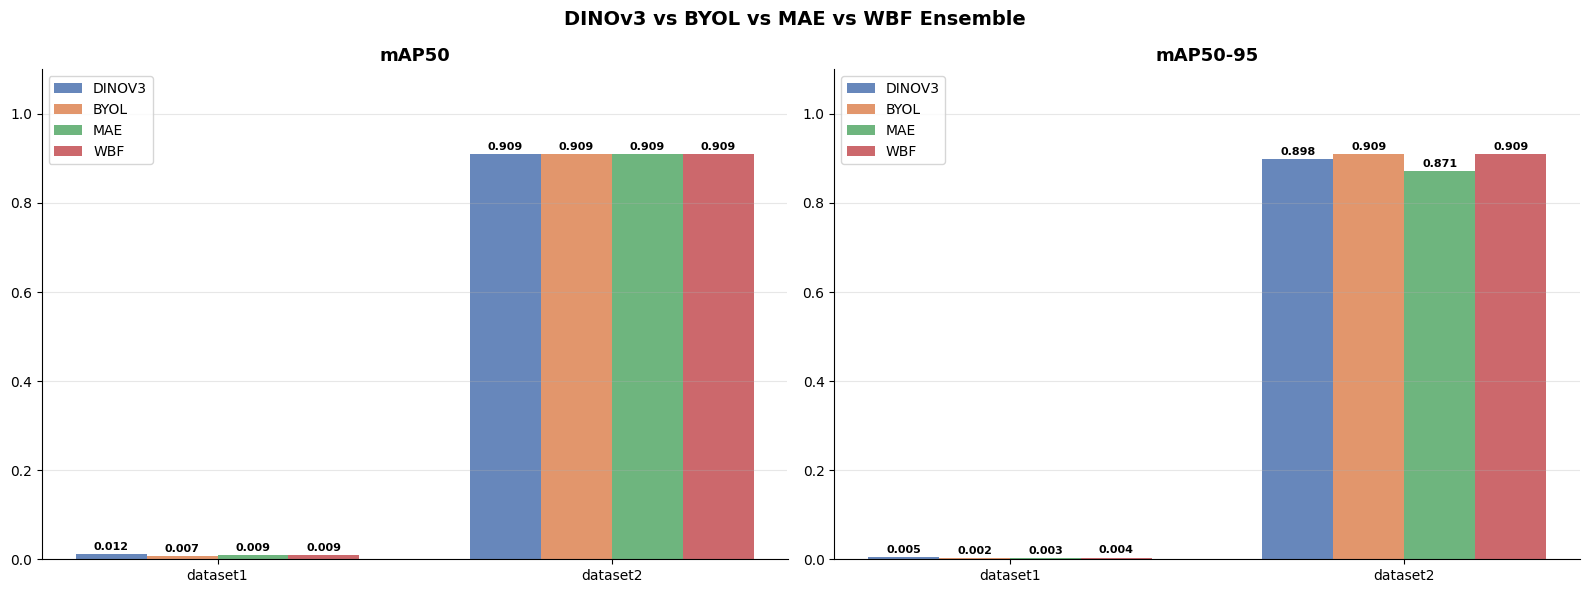

✅ Saved: wbf_comparison.png


In [27]:
# ── Cell 10: Bar chart comparison ──

if not eval_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    colors = {'DINOV3': '#4C72B0', 'BYOL': '#DD8452', 'MAE': '#55A868', 'WBF': '#C44E52'}

    for ax, metric in zip(axes, ['mAP50', 'mAP50-95']):
        datasets = eval_df['Dataset'].unique()
        models   = ['DINOV3', 'BYOL', 'MAE', 'WBF']
        x, w     = np.arange(len(datasets)), 0.18
        for i, m in enumerate(models):
            vals = [eval_df[(eval_df['Dataset']==d) & (eval_df['Model']==m)][metric].values
                    for d in datasets]
            vals = [v[0] if len(v) else 0 for v in vals]
            bars = ax.bar(x + i*w, vals, w, label=m, color=colors[m], alpha=0.85)
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        ax.set_title(metric, fontsize=13, fontweight='bold')
        ax.set_xticks(x + w*1.5)
        ax.set_xticklabels(datasets)
        ax.set_ylim(0, 1.1)
        ax.legend(); ax.grid(axis='y', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)

    fig.suptitle('DINOv3 vs BYOL vs MAE vs WBF Ensemble', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT}/wbf_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: wbf_comparison.png')

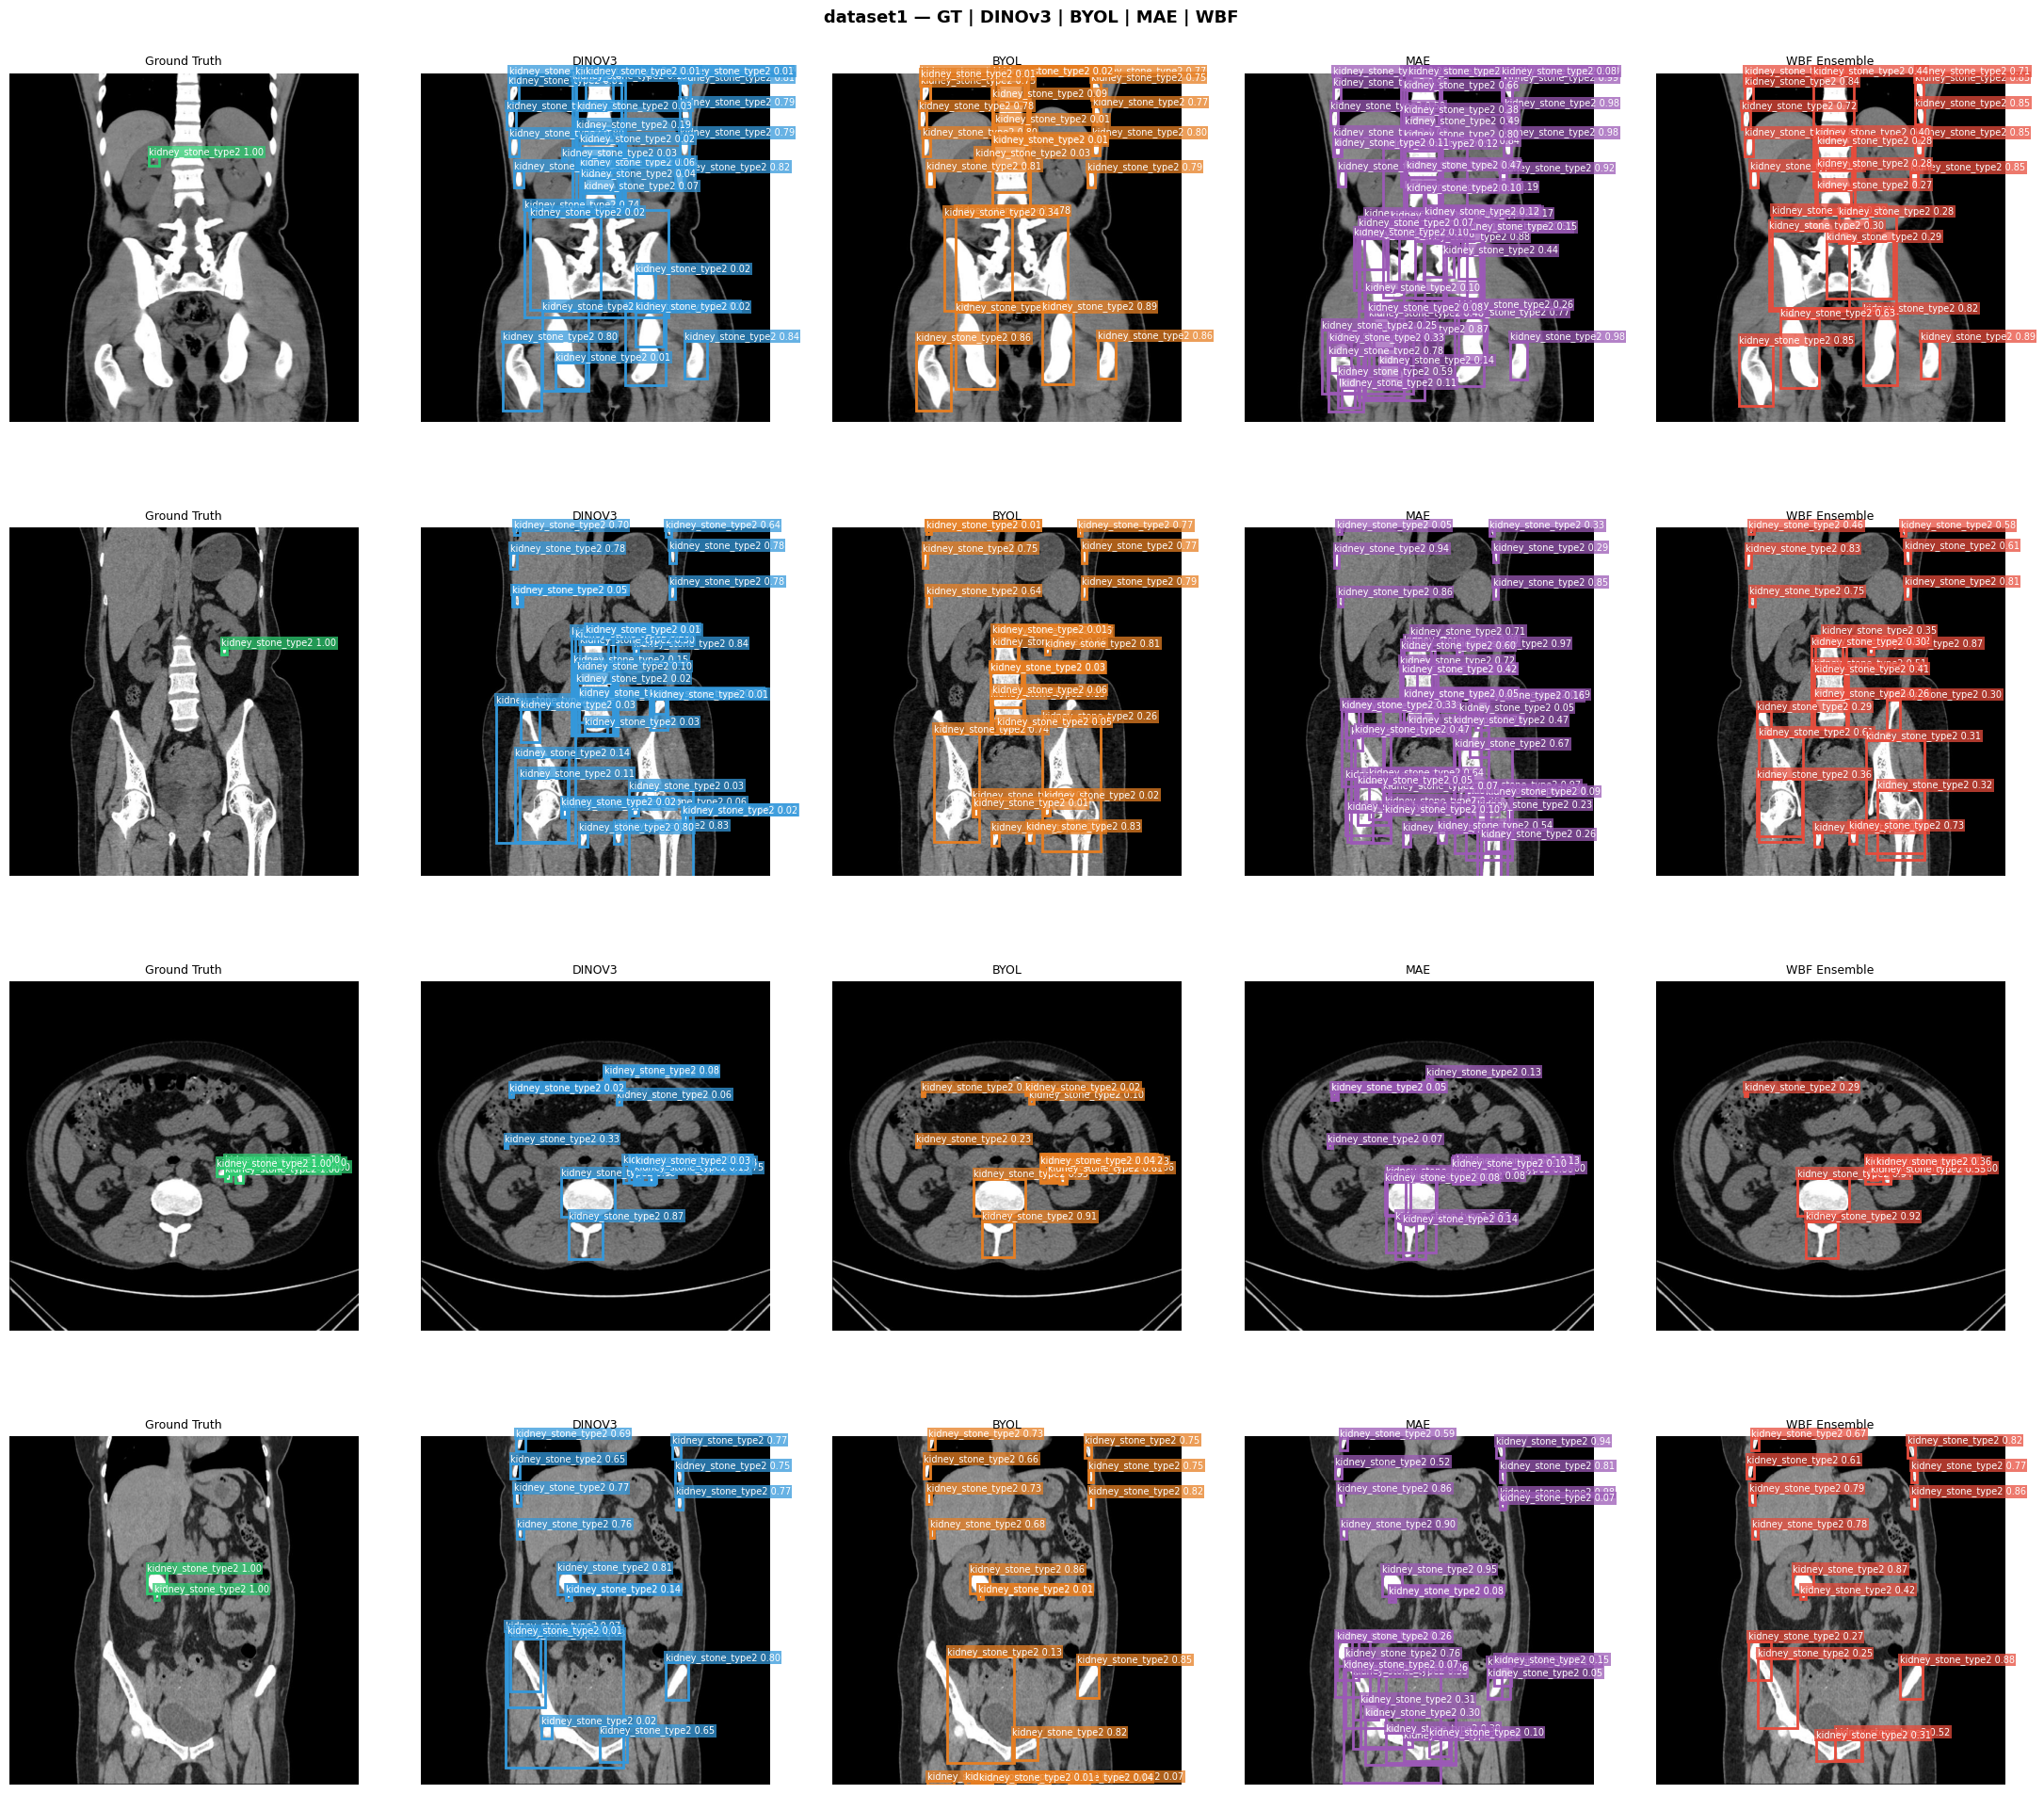

✅ Saved: dataset1_visualisation.png


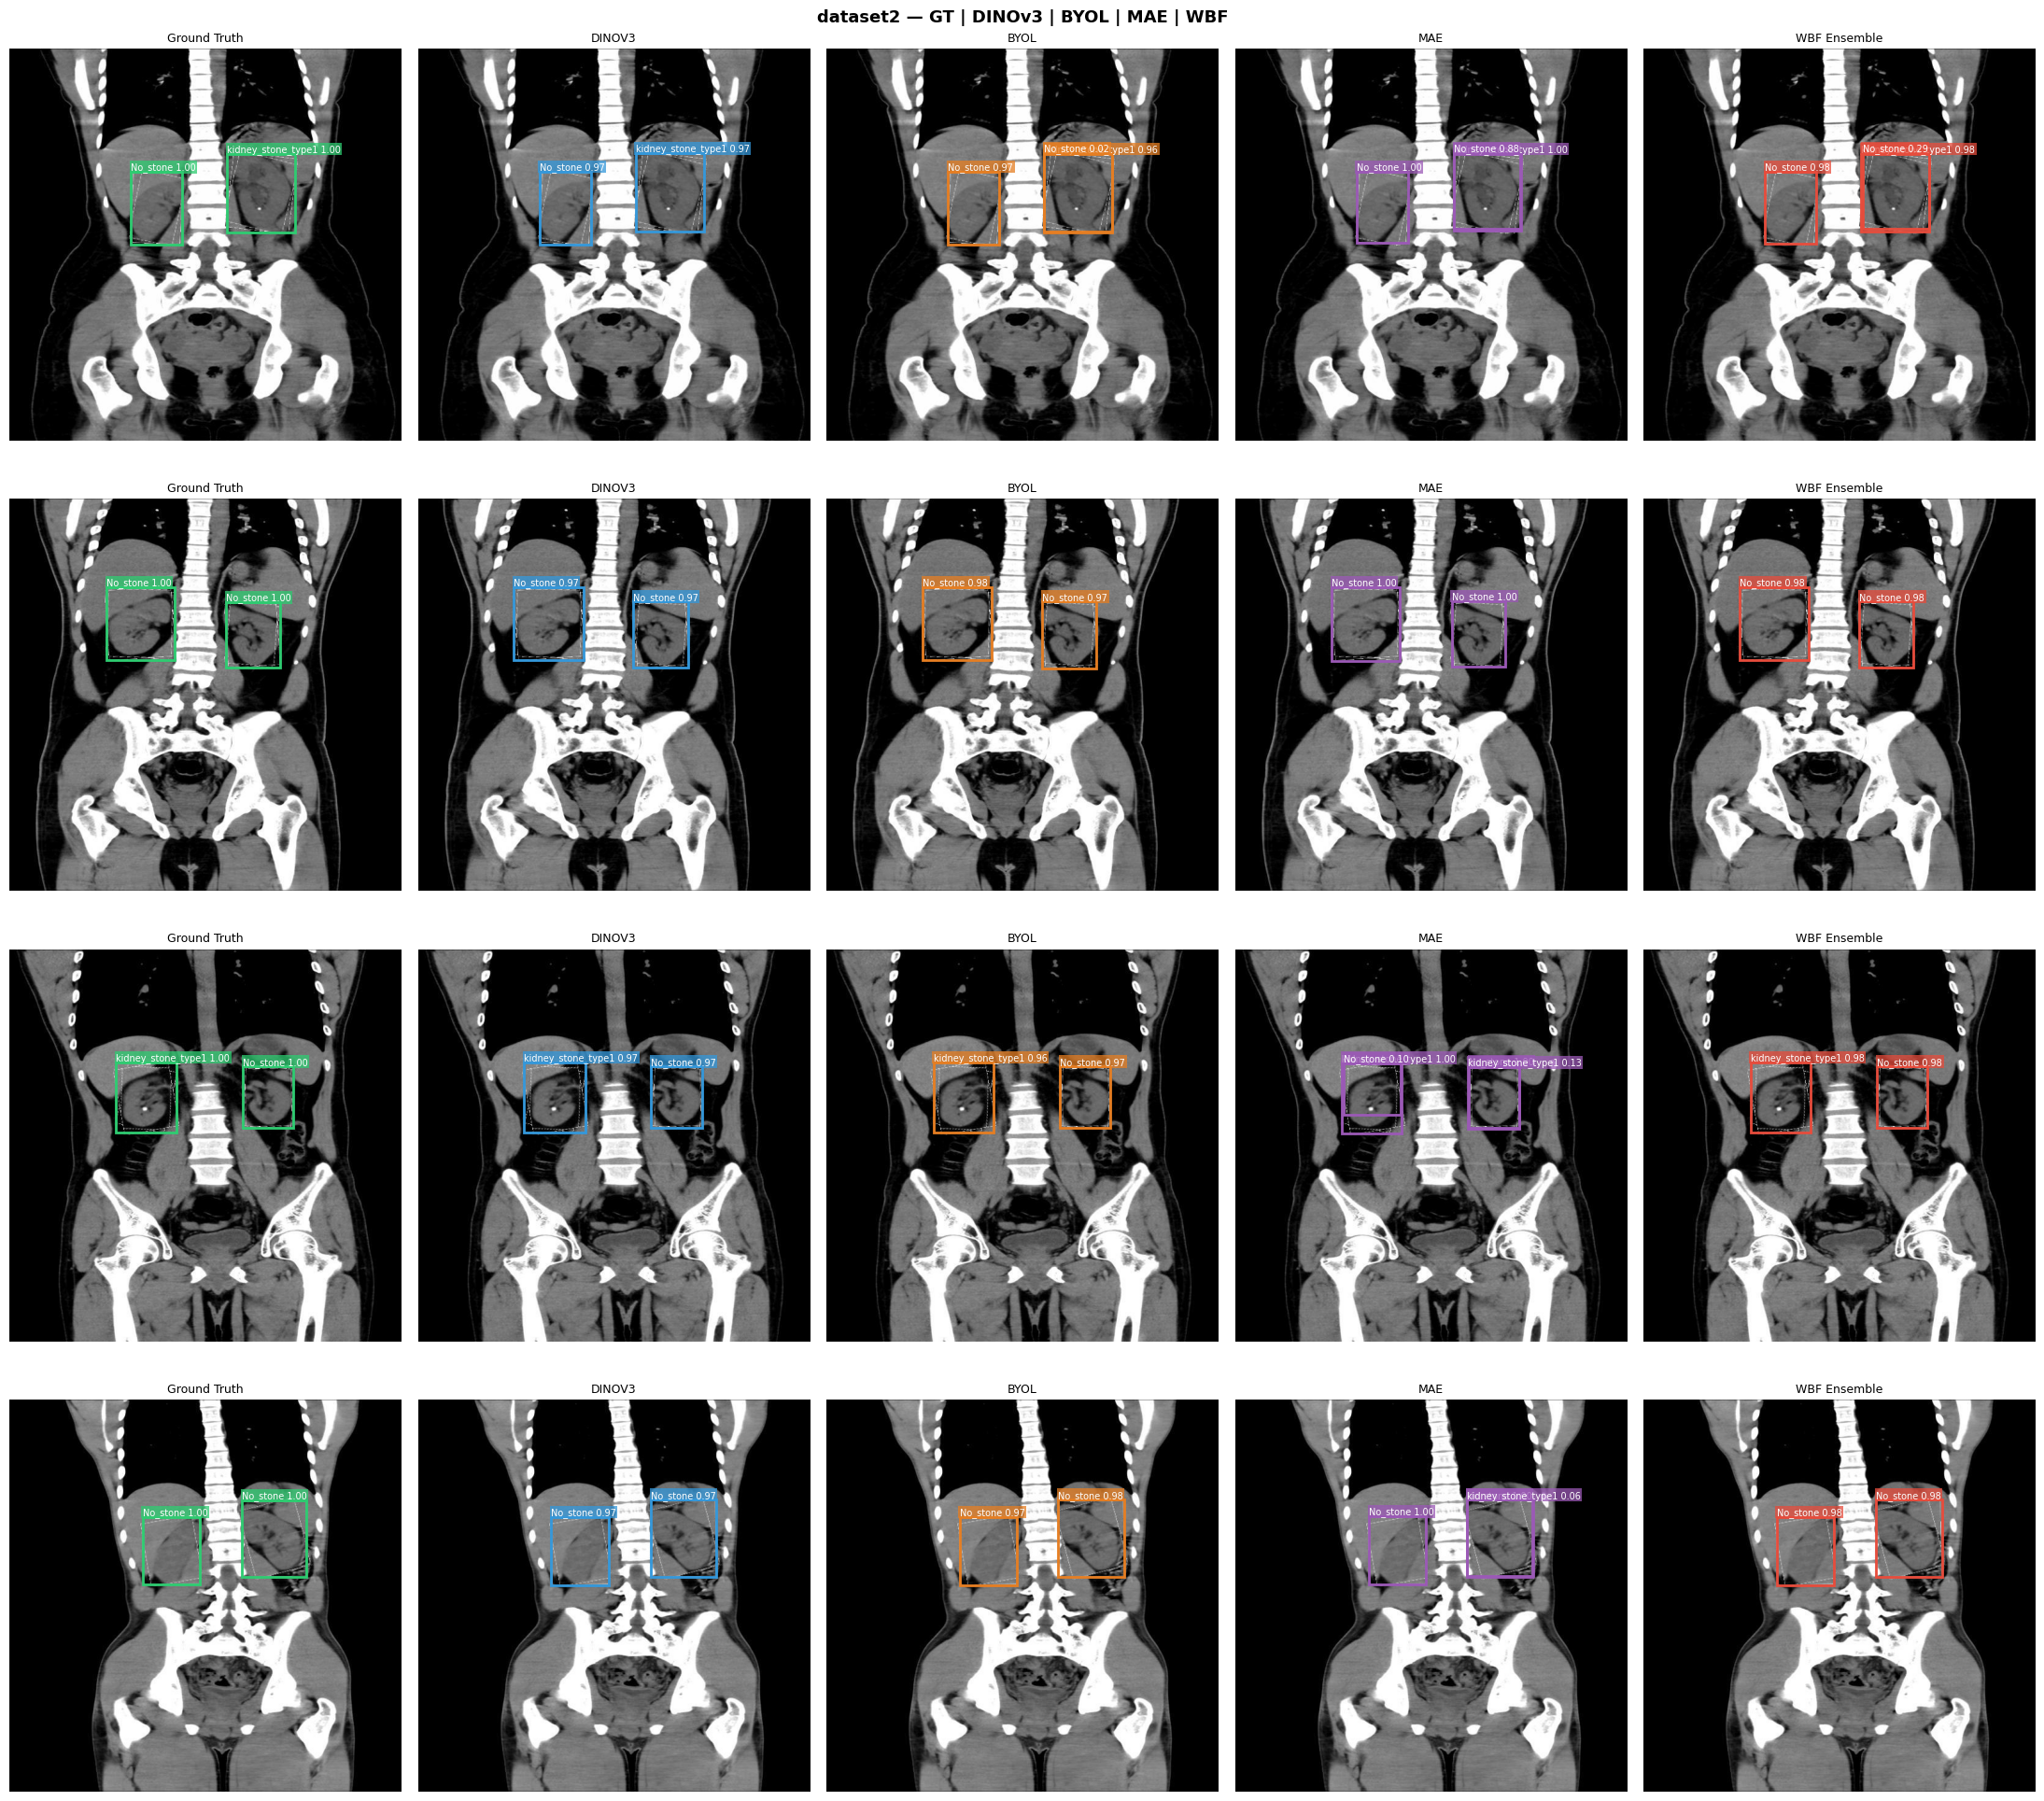

✅ Saved: dataset2_visualisation.png


In [28]:
# ── Cell 11: Visualise predictions (4 sample images per dataset) ──

def draw(ax, img, boxes, scores, labels, classes, color, title):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    h, w = img.shape[:2]
    for box, score, label in zip(boxes, scores, labels):
        x1,y1,x2,y2 = int(box[0]*w),int(box[1]*h),int(box[2]*w),int(box[3]*h)
        ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'))
        name = classes[int(label)] if int(label)<len(classes) else str(int(label))
        ax.text(x1, max(y1-4,0), f'{name} {score:.2f}', color='white', fontsize=7,
            bbox=dict(facecolor=color, alpha=0.75, pad=1, edgecolor='none'))
    ax.set_title(title, fontsize=9); ax.axis('off')


for ds_name, cfg in MODELS.items():
    gt     = all_gt.get(ds_name, {})
    wbf    = {r['stem']: r for r in all_results.get(ds_name, [])}
    ind    = all_ind_preds.get(ds_name, {})
    cls    = cfg['classes']
    img_dir = Path(cfg['test_images'])

    stems = [s for s, g in gt.items() if len(g['boxes']) > 0]
    if not stems: continue
    random.seed(42)
    samples = random.sample(stems, min(4, len(stems)))

    fig, axes = plt.subplots(len(samples), 5, figsize=(22, 5*len(samples)))
    if len(samples) == 1: axes = axes[np.newaxis, :]
    fig.suptitle(f'{ds_name} — GT | DINOv3 | BYOL | MAE | WBF', fontsize=13, fontweight='bold')

    for row, stem in enumerate(samples):
        img_path = None
        for ext in ['.jpg','.jpeg','.png']:
            p = img_dir / (stem + ext)
            if p.exists(): img_path = p; break
        if not img_path: continue
        img = cv2.imread(str(img_path))

        g = gt.get(stem, {'boxes':[], 'labels':[]})
        draw(axes[row,0], img, g['boxes'], [1.0]*len(g['boxes']), g['labels'], cls, '#2ecc71', 'Ground Truth')

        clrs = {'dinov3':'#3498db', 'byol':'#e67e22', 'mae':'#9b59b6'}
        for col, mname in enumerate(['dinov3','byol','mae'], start=1):
            plist = ind.get(mname, [])
            item  = next((x for x in plist if x['stem']==stem), {'boxes':[],'scores':[],'labels':[]})
            draw(axes[row,col], img, item['boxes'], item['scores'], item['labels'],
                 cls, clrs[mname], mname.upper())

        w_item = wbf.get(stem, {'boxes':[],'scores':[],'labels':[]})
        draw(axes[row,4], img, w_item['boxes'], w_item['scores'], w_item['labels'],
             cls, '#e74c3c', 'WBF Ensemble')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT}/{ds_name}_visualisation.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {ds_name}_visualisation.png')

In [29]:
# ── Cell 12: Save predictions as COCO JSON ──

for ds_name in MODELS:
    out = []
    for item in all_results.get(ds_name, []):
        for box, score, label in zip(item['boxes'], item['scores'], item['labels']):
            x1,y1,x2,y2 = box
            out.append({'image_id': item['stem'],
                        'bbox': [round(x1*IMG_SIZE,2), round(y1*IMG_SIZE,2),
                                 round((x2-x1)*IMG_SIZE,2), round((y2-y1)*IMG_SIZE,2)],
                        'score': round(score,4),
                        'category_id': int(label)})
    path = f'{OUTPUT}/{ds_name}_wbf_predictions.json'
    with open(path,'w') as f: json.dump(out, f, indent=2)
    print(f'✅ {ds_name}: {len(out)} detections → {path}')

print('\n📁 All outputs in /kaggle/working/')
print('   wbf_evaluation.csv')
print('   wbf_comparison.png')
print('   dataset1_wbf_predictions.json')
print('   dataset2_wbf_predictions.json')
print('   dataset1_visualisation.png')
print('   dataset2_visualisation.png')

if not eval_df.empty:
    print('\n📊 Final Results:')
    try:
        from IPython.display import display
        display(eval_df.style.background_gradient(
            subset=['mAP50','mAP50-95','F1'], cmap='RdYlGn')
            .format({'mAP50':'{:.4f}','mAP50-95':'{:.4f}',
                     'Precision':'{:.4f}','Recall':'{:.4f}','F1':'{:.4f}'}))
    except:
        print(eval_df.to_string(index=False))

✅ dataset1: 13726 detections → /kaggle/working/dataset1_wbf_predictions.json
✅ dataset2: 1987 detections → /kaggle/working/dataset2_wbf_predictions.json

📁 All outputs in /kaggle/working/
   wbf_evaluation.csv
   wbf_comparison.png
   dataset1_wbf_predictions.json
   dataset2_wbf_predictions.json
   dataset1_visualisation.png
   dataset2_visualisation.png

📊 Final Results:


,Dataset,Model,mAP50,mAP50-95,Precision,Recall,F1
0,dataset1,DINOV3,0.0120,0.0047,0.0089,0.6354,0.0175
1,dataset1,BYOL,0.0067,0.0024,0.0084,0.5000,0.0165
2,dataset1,MAE,0.0088,0.0030,0.0060,0.5166,0.0118
3,dataset1,WBF,0.0087,0.0036,0.0126,0.4779,0.0246
4,dataset2,DINOV3,0.9091,0.8981,0.9126,0.9959,0.9524
5,dataset2,BYOL,0.9091,0.9091,0.8906,0.9912,0.9382
6,dataset2,MAE,0.9091,0.8707,0.7289,0.9959,0.8417
7,dataset2,WBF,0.9091,0.9089,0.9628,0.9912,0.9768
